# Factor AI Lab 04 — robust PDV tracking, uncertainty, and abstention (draft)

Notebook 02 asked whether a CNN could replace a peak-ridge estimator. This draft gives machine learning a narrower and more useful job: **correct a strong conventional estimate, estimate uncertainty, and admit ambiguity**.

## Explain it like I am five
The bright line in a spectrogram is like a trail through a snowy forest. Picking the brightest spot in every photograph can jump onto the wrong trail. A continuity tracker remembers where the trail was one moment ago. The residual CNN acts like a helper that suggests small corrections and raises its hand when two trails look believable.

## Draft evaluation contract
- **Decision:** determine when a PDV-derived speed trace is usable and when another measurement or human review is required.
- **Observed:** detector voltage, sample rate, wavelength, and declared calibration metadata.
- **Outputs:** speed magnitude, uncertainty scale, and abstention probability at every STFT frame.
- **Baselines:** independent peak ridge and a continuity-aware dynamic-programming ridge.
- **Candidate:** residual temporal CNN supplied the same spectrogram and baseline trace.
- **Development regimes:** nominal, low SNR, dropout, and two returns.
- **Primary metrics:** per-shot MAE, bias, tail error, interval coverage/width, abstention rate, and retained-versus-abstained error.
- **Failure gates:** no average may hide a failed regime; false confidence on ambiguous frames is a failure.
- **Locked test:** generated from separate seeds and remains closed until `OPEN_LOCKED_TEST=True`.
- **Boundary:** simulator truth is exact only inside this generator. Real PDV validation remains separate.

In [1]:
from dataclasses import dataclass
import copy, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import ShortTimeFFT
import torch
from torch import nn

sns.set_theme(style='whitegrid', context='notebook')
DEVICE=torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
FS=4e9; WAVELENGTH=1550e-9; N=1024; MAX_SPEED=1300.; N_BINS=96
T=np.arange(N)/FS; VGRID=np.linspace(0,MAX_SPEED,N_BINS)
OPEN_LOCKED_TEST=True
LOCKED_TEST_ID='pdv-robust-v1-seeds-30000-30047'
print(f'Python {platform.python_version()} | PyTorch {torch.__version__} | {DEVICE}')

Python 3.12.14 | PyTorch 2.14.0 | mps


## 1. Harder forward model
Every shot records the nuisance regime and an evaluator-only ambiguity mask. The two-return case is intentionally not forced into a unique answer where the secondary return is comparable to the primary return.

In [2]:
REGIMES=('nominal','low_snr','dropout','dual_return')

def smoothstep(x):
    x=np.clip(x,0,1); return x*x*(3-2*x)

def simulate(seed,regime):
    rng=np.random.default_rng(seed); u=np.linspace(0,1,N)
    speed=np.clip(rng.uniform(70,180)+rng.uniform(480,780)*smoothstep((u-rng.uniform(.08,.2))/rng.uniform(.5,.78))
                  +rng.uniform(15,65)*np.sin(2*np.pi*(rng.uniform(.7,1.7)*u+rng.random())),20,MAX_SPEED-180)
    amp=1+.2*np.sin(2*np.pi*(rng.uniform(.4,1.3)*u+rng.random()))
    sigma=.10; secondary=np.zeros(N); ambiguous=np.zeros(N,dtype=bool)
    if regime=='low_snr': sigma=.32
    if regime=='dropout':
        center=rng.uniform(.4,.75); width=rng.uniform(.025,.065)
        amp*=1-rng.uniform(.75,.98)*np.exp(-.5*((u-center)/width)**2)
        ambiguous=np.abs(u-center)<1.4*width
    if regime=='dual_return':
        center=rng.uniform(.35,.68); width=rng.uniform(.07,.14); envelope=np.exp(-.5*((u-center)/width)**2)
        other=np.clip(speed+rng.choice([-1,1])*rng.uniform(110,260),0,MAX_SPEED)
        phase2=2*np.pi*np.cumsum(2*other/WAVELENGTH)/FS+rng.uniform(0,2*np.pi)
        ratio=rng.uniform(.55,1.05)*envelope; secondary=ratio*np.cos(phase2)
        ambiguous=ratio>.55
    phase=2*np.pi*np.cumsum(2*speed/WAVELENGTH)/FS+rng.uniform(0,2*np.pi)
    drift=rng.uniform(.04,.16)*np.sin(2*np.pi*rng.uniform(3e6,18e6)*T+rng.random())
    voltage=amp*np.cos(phase)+secondary+drift+rng.normal(0,sigma,N)
    return {'seed':seed,'regime':regime,'voltage':voltage.astype('float32'),
            'speed':speed.astype('float32'),'ambiguous':ambiguous}

train=[simulate(10000+i,REGIMES[i%4]) for i in range(64)]
dev=[simulate(20000+i,REGIMES[i%4]) for i in range(32)]
locked=[simulate(30000+i,REGIMES[i%4]) for i in range(48)]
print('shots:',len(train),'train,',len(dev),'development,',len(locked),'locked test')

shots: 64 train, 32 development, 48 locked test


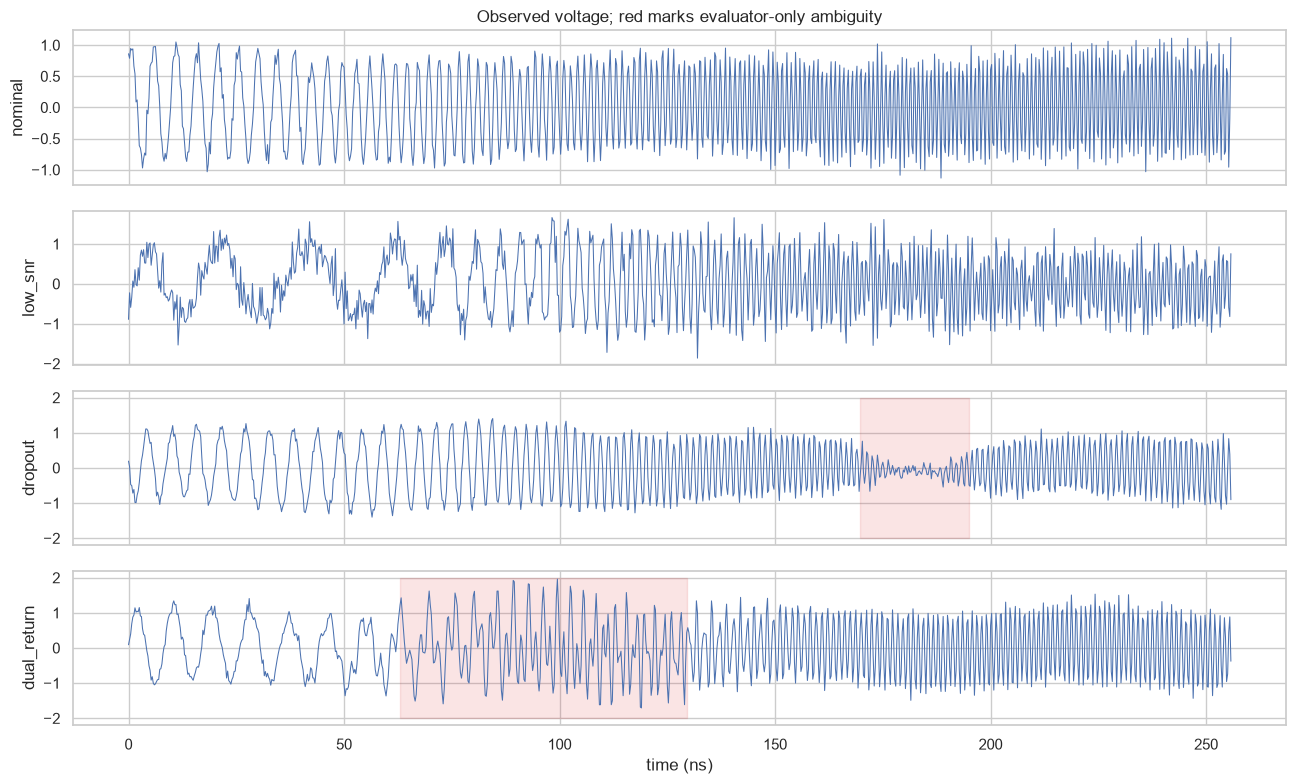

In [3]:
fig,axes=plt.subplots(4,1,figsize=(13,8),sharex=True)
for ax,regime in zip(axes,REGIMES):
    shot=next(s for s in dev if s['regime']==regime)
    ax.plot(T*1e9,shot['voltage'],linewidth=.75); ax.set_ylabel(regime)
    ax.fill_between(T*1e9,-2,2,where=shot['ambiguous'],color='tab:red',alpha=.12)
axes[-1].set_xlabel('time (ns)'); axes[0].set_title('Observed voltage; red marks evaluator-only ambiguity')
plt.tight_layout(); plt.show()

## 2. Two conventional baselines
The independent ridge chooses the brightest bin at each time. The continuity tracker chooses an entire path, trading spectral brightness against implausibly large jumps. The continuity penalty must be selected on development shots only.

In [4]:
STFT=ShortTimeFFT.from_window('hann',fs=FS,nperseg=96,noverlap=72,mfft=768,scale_to='magnitude')

def transform(shot):
    mag=np.abs(STFT.stft(shot['voltage'])); ft=STFT.t(N)
    keep=(ft>=0)&(ft<=T[-1]); mag=mag[:,keep]; ft=ft[keep]
    native=WAVELENGTH*STFT.f/2; usable=native<=MAX_SPEED
    spec=np.stack([np.interp(VGRID,native[usable],mag[usable,j]) for j in range(mag.shape[1])],axis=1)
    spec=np.clip((20*np.log10(spec/(spec.max()+1e-12)+1e-6)+60)/60,0,1).astype('float32')
    truth=np.interp(ft,T,shot['speed']).astype('float32')
    ambiguity=np.interp(ft,T,shot['ambiguous'].astype(float))>.35
    return spec,truth,ambiguity,ft

def peak_ridge(spec): return VGRID[np.argmax(spec,axis=0)]

def continuity_ridge(spec,jump_penalty=.035):
    bins,times=spec.shape; distance=np.abs(np.arange(bins)[:,None]-np.arange(bins)[None,:])
    score=np.empty_like(spec); back=np.zeros((bins,times),dtype=np.int16); score[:,0]=spec[:,0]
    for t in range(1,times):
        choices=score[:,t-1][None,:]-jump_penalty*distance
        back[:,t]=np.argmax(choices,axis=1); score[:,t]=spec[:,t]+choices[np.arange(bins),back[:,t]]
    path=np.empty(times,dtype=int); path[-1]=np.argmax(score[:,-1])
    for t in range(times-1,0,-1): path[t-1]=back[path[t],t]
    return VGRID[path]

def mae(pred,truth,mask=None):
    if mask is None: mask=np.ones_like(truth,dtype=bool)
    return np.mean(np.abs(pred[mask]-truth[mask]))

penalties=[0,.01,.02,.035,.05,.08,.12]
rows=[]
for penalty in penalties:
    errors=[]
    for shot in dev:
        spec,truth,amb,_=transform(shot); errors.append(mae(continuity_ridge(spec,penalty),truth,~amb))
    rows.append({'jump_penalty':penalty,'development_MAE':np.mean(errors)})
baseline_search=pd.DataFrame(rows); BEST_PENALTY=float(baseline_search.loc[baseline_search.development_MAE.idxmin(),'jump_penalty'])
display(baseline_search.round(2)); print('Selected continuity penalty:',BEST_PENALTY)

,jump_penalty,development_MAE
0,0.00,3.71
1,0.01,3.80
2,0.02,4.17
3,0.04,4.56
4,0.05,4.93
5,0.08,5.54
6,0.12,6.28


Selected continuity penalty: 0.0


## 3. Residual CNN with uncertainty and abstention
The CNN receives 96 spectral channels plus the normalized continuity trace and peak prominence. It predicts three quantities per time: a bounded correction, a positive uncertainty scale, and an ambiguity logit. The velocity loss is Gaussian negative log likelihood; ambiguity uses binary cross entropy.

In [5]:
class ResidualPDVCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.body=nn.Sequential(nn.Conv1d(N_BINS+2,64,5,padding=2),nn.GELU(),
                                nn.Conv1d(64,48,5,padding=2),nn.GELU(),
                                nn.Conv1d(48,24,3,padding=1),nn.GELU())
        self.head=nn.Conv1d(24,3,1)
    def forward(self,x,base):
        raw=self.head(self.body(x)); correction=140*torch.tanh(raw[:,0])
        mean=torch.clamp(base+correction,0,MAX_SPEED)
        sigma=3+torch.nn.functional.softplus(raw[:,1])*45
        return mean,sigma,raw[:,2]

def tensors(shots):
    features=[]; bases=[]; truths=[]; ambiguities=[]
    for shot in shots:
        spec,truth,amb,_=transform(shot); base=continuity_ridge(spec,BEST_PENALTY).astype('float32')
        ordered=np.sort(spec,axis=0); prominence=(ordered[-1]-ordered[-2]).astype('float32')
        x=np.concatenate([spec,(base/MAX_SPEED)[None],prominence[None]],axis=0)
        features.append(x); bases.append(base); truths.append(truth); ambiguities.append(amb.astype('float32'))
    return tuple(torch.tensor(np.stack(v),device=DEVICE) for v in (features,bases,truths,ambiguities))

def train_model(seed,epochs=800):
    torch.manual_seed(seed); model=ResidualPDVCNN().to(DEVICE); opt=torch.optim.AdamW(model.parameters(),lr=1e-3)
    x,b,y,a=tensors(train); xd,bd,yd,ad=tensors(dev); best={'mae':np.inf,'state':None}; history=[]
    for epoch in range(1,epochs+1):
        model.train(); opt.zero_grad(); mean,sigma,logit=model(x,b)
        usable=1-a; nll=((.5*((y-mean)/sigma)**2+torch.log(sigma))*usable).sum()/usable.sum()
        ambiguity=nn.functional.binary_cross_entropy_with_logits(logit,a); loss=nll+.35*ambiguity
        loss.backward(); opt.step(); model.eval()
        with torch.no_grad():
            md,sd,ld=model(xd,bd); dev_mae=((md-yd).abs()*(1-ad)).sum()/(1-ad).sum()
        if dev_mae.item()<best['mae']: best={'mae':dev_mae.item(),'state':copy.deepcopy(model.state_dict())}
        if epoch==1 or epoch%20==0: history.append({'epoch':epoch,'dev_MAE':dev_mae.item(),'loss':loss.item()})
    model.load_state_dict(best['state']); return model,pd.DataFrame(history),best['mae']

runs=[]; started=time.perf_counter()
for seed in (41, 42, 43, 44, 45, 46, 47, 48):
    model,history,score=train_model(seed); runs.append({'seed':seed,'model':model,'history':history,'dev_mae':score})
    print('seed',seed,'development MAE',round(score,2),'m/s')
best=min(runs,key=lambda r:r['dev_mae']); print('training seconds:',round(time.perf_counter()-started,1))

seed 41 development MAE 3.71 m/s


seed 42 development MAE 3.7 m/s


seed 43 development MAE 3.69 m/s


seed 44 development MAE 3.69 m/s


seed 45 development MAE 3.7 m/s


seed 46 development MAE 3.72 m/s


seed 47 development MAE 3.72 m/s


seed 48 development MAE 3.69 m/s
training seconds: 18.1


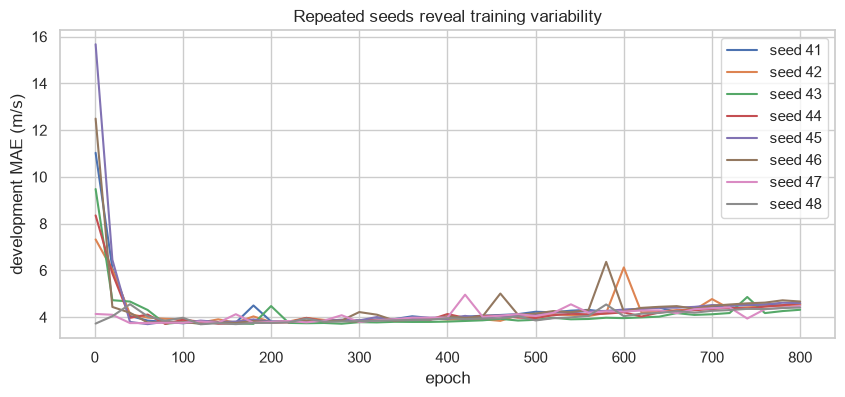

In [6]:
fig,ax=plt.subplots(figsize=(10,4))
for run in runs: ax.plot(run['history'].epoch,run['history'].dev_MAE,label=f"seed {run['seed']}")
ax.set(xlabel='epoch',ylabel='development MAE (m/s)',title='Repeated seeds reveal training variability'); ax.legend(); plt.show()

## 4. Development diagnostics: does the model know when it may be wrong?

Velocity MAE alone does not test the new capability. We now ask three separate questions on development shots:

1. **Correction:** is the residual CNN more accurate than the conventional trace in every regime?
2. **Uncertainty:** does a nominal 95% interval contain the synthetic truth about 95% of the time, without becoming uselessly wide?
3. **Abstention:** do high-risk frames actually contain more errors and ambiguity?

The raw neural `sigma` is not assumed to be calibrated. A single multiplicative scale is fitted on usable development frames. This development report is optimistic because the same development set selected the best epoch; the locked test is the generalization check.

In [7]:
def evaluate_shots(shots, model):
    """Return shot-level errors, frame-level predictions, and one example per regime."""
    shot_rows=[]; frame_rows=[]; examples={}
    model.eval()
    for shot in shots:
        spec,truth,amb,ft=transform(shot)
        peak=peak_ridge(spec).astype('float32')
        cont=continuity_ridge(spec,BEST_PENALTY).astype('float32')
        ordered=np.sort(spec,axis=0)
        prominence=(ordered[-1]-ordered[-2]).astype('float32')
        xin=np.concatenate([spec,(cont/MAX_SPEED)[None],prominence[None]],axis=0)
        with torch.no_grad():
            mean,sigma,logit=model(
                torch.tensor(xin[None],device=DEVICE),
                torch.tensor(cont[None],device=DEVICE,dtype=torch.float32))
        mean=mean.cpu().numpy()[0]; sigma=sigma.cpu().numpy()[0]
        prob=torch.sigmoid(logit).cpu().numpy()[0]
        usable=~amb
        for name,pred in [('peak',peak),('continuity',cont),('residual CNN',mean)]:
            err=pred[usable]-truth[usable]
            shot_rows.append({'shot':shot['seed'],'regime':shot['regime'],'method':name,
                              'MAE':np.mean(np.abs(err)),'bias':np.mean(err),
                              'p95_abs_error':np.quantile(np.abs(err),.95)})
        for j in range(len(truth)):
            frame_rows.append({'shot':shot['seed'],'regime':shot['regime'],'time_ns':ft[j]*1e9,
                               'truth':truth[j],'peak':peak[j],'continuity':cont[j],
                               'cnn':mean[j],'raw_sigma':sigma[j],'ambiguity_prob':prob[j],
                               'ambiguous':bool(amb[j]),'prominence':prominence[j]})
        examples.setdefault(shot['regime'],{'shot':shot,'time':ft,'truth':truth,'amb':amb,
                                            'continuity':cont,'cnn':mean,'raw_sigma':sigma,
                                            'ambiguity_prob':prob})
    return pd.DataFrame(shot_rows),pd.DataFrame(frame_rows),examples

def risk_curve(frame_df, risk_column='calibrated_sigma'):
    """Retain the lowest-risk usable frames and measure their error."""
    usable=frame_df.loc[~frame_df.ambiguous].copy()
    usable['abs_error']=(usable.cnn-usable.truth).abs()
    ordered=usable.sort_values(risk_column)
    rows=[]
    for coverage in (1.0,.95,.90,.80,.70,.50):
        n=max(1,int(np.ceil(coverage*len(ordered))))
        kept=ordered.iloc[:n]
        rows.append({'retained_fraction':coverage,'abstained_fraction':1-coverage,
                     'retained_MAE':kept.abs_error.mean(),
                     'retained_p95':kept.abs_error.quantile(.95)})
    return pd.DataFrame(rows)

dev_shots,dev_frames,dev_examples=evaluate_shots(dev,best['model'])
usable_dev=dev_frames.loc[~dev_frames.ambiguous]
standardized=np.abs(usable_dev.cnn-usable_dev.truth)/np.maximum(usable_dev.raw_sigma,1e-6)
SIGMA_SCALE=float(np.quantile(standardized,.95)/1.96)
dev_frames['calibrated_sigma']=dev_frames.raw_sigma*SIGMA_SCALE
AMBIGUITY_THRESHOLD=.50
print('Development-fitted sigma multiplier:',round(SIGMA_SCALE,3))

Development-fitted sigma multiplier: 0.872


In [8]:
velocity_dev=(dev_shots.groupby(['regime','method'])
              [['MAE','bias','p95_abs_error']].mean().round(2))
interval_dev=(dev_frames.loc[~dev_frames.ambiguous].assign(
    covered=lambda d: np.abs(d.cnn-d.truth)<=1.96*d.calibrated_sigma,
    width_95=lambda d: 2*1.96*d.calibrated_sigma)
    .groupby('regime')[['covered','width_95']].mean()
    .rename(columns={'covered':'coverage_95'}).round(3))
ambiguous_dev=dev_frames.ambiguous
false_conf_dev=float((dev_frames.loc[ambiguous_dev,'ambiguity_prob']<AMBIGUITY_THRESHOLD).mean())
false_alarm_dev=float((dev_frames.loc[~ambiguous_dev,'ambiguity_prob']>=AMBIGUITY_THRESHOLD).mean())
ambiguity_dev=pd.DataFrame([{'threshold':AMBIGUITY_THRESHOLD,
    'ambiguous_recall':1-false_conf_dev,'ambiguous_false_confidence':false_conf_dev,
    'usable_false_alarm':false_alarm_dev,'ambiguous_prevalence':ambiguous_dev.mean()}]).round(3)
risk_dev=risk_curve(dev_frames)

print('Velocity errors: shot means (m/s)')
display(velocity_dev)
print('Calibrated CNN intervals on usable frames')
display(interval_dev)
print('Ambiguity classifier')
display(ambiguity_dev)
print('Risk/coverage using predicted uncertainty')
display(risk_dev.round(3))

Velocity errors: shot means (m/s)


MAE  bias  p95_abs_error
regime      method                                 
dropout     continuity    3.60 -0.06           6.94
            peak          3.60 -0.06           6.94
            residual CNN  3.61 -0.20           6.99
dual_return continuity    3.97  0.08           7.66
            peak          3.97  0.08           7.66
            residual CNN  3.96 -0.10           7.39
low_snr     continuity    3.80  0.88           7.82
            peak          3.80  0.88           7.82
            residual CNN  3.71  0.39           7.72
nominal     continuity    3.46  0.04           6.65
            peak          3.46  0.04           6.65
            residual CNN  3.51 -0.13           6.68

Calibrated CNN intervals on usable frames


,coverage_95,width_95
regime,,
dropout,0.966,16.625
dual_return,0.972,16.299
low_snr,0.875,13.771
nominal,0.991,16.073


Ambiguity classifier


,threshold,ambiguous_recall,ambiguous_false_confidence,usable_false_alarm,ambiguous_prevalence
0,0.5,0.0,1.0,0.0,0.076


Risk/coverage using predicted uncertainty


,retained_fraction,abstained_fraction,retained_MAE,retained_p95
0,1.00,0.00,3.687,7.294
1,0.95,0.05,3.632,7.161
2,0.90,0.10,3.635,7.121
3,0.80,0.20,3.643,7.135
4,0.70,0.30,3.654,7.159
5,0.50,0.50,3.656,7.251


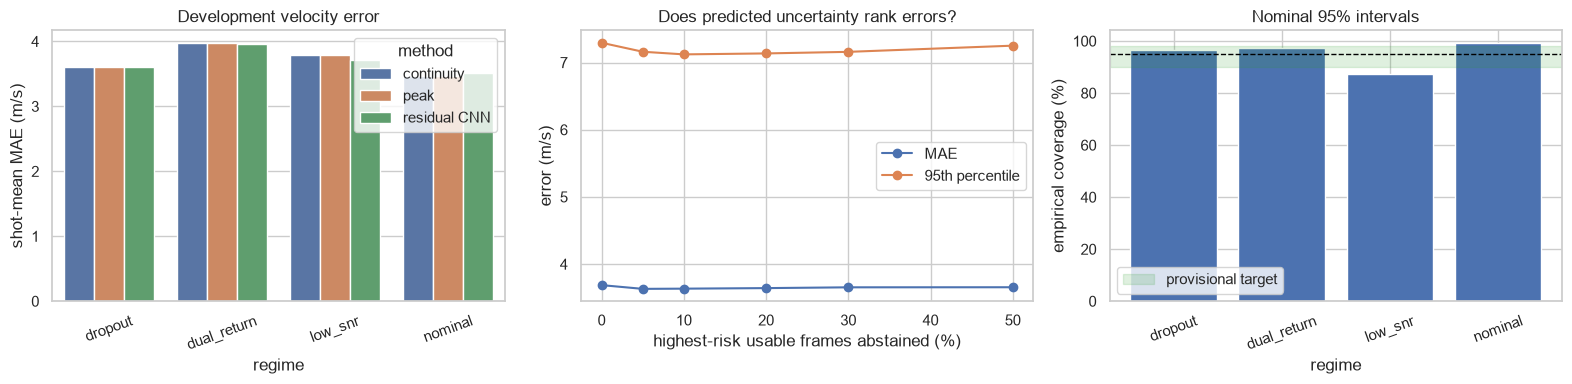

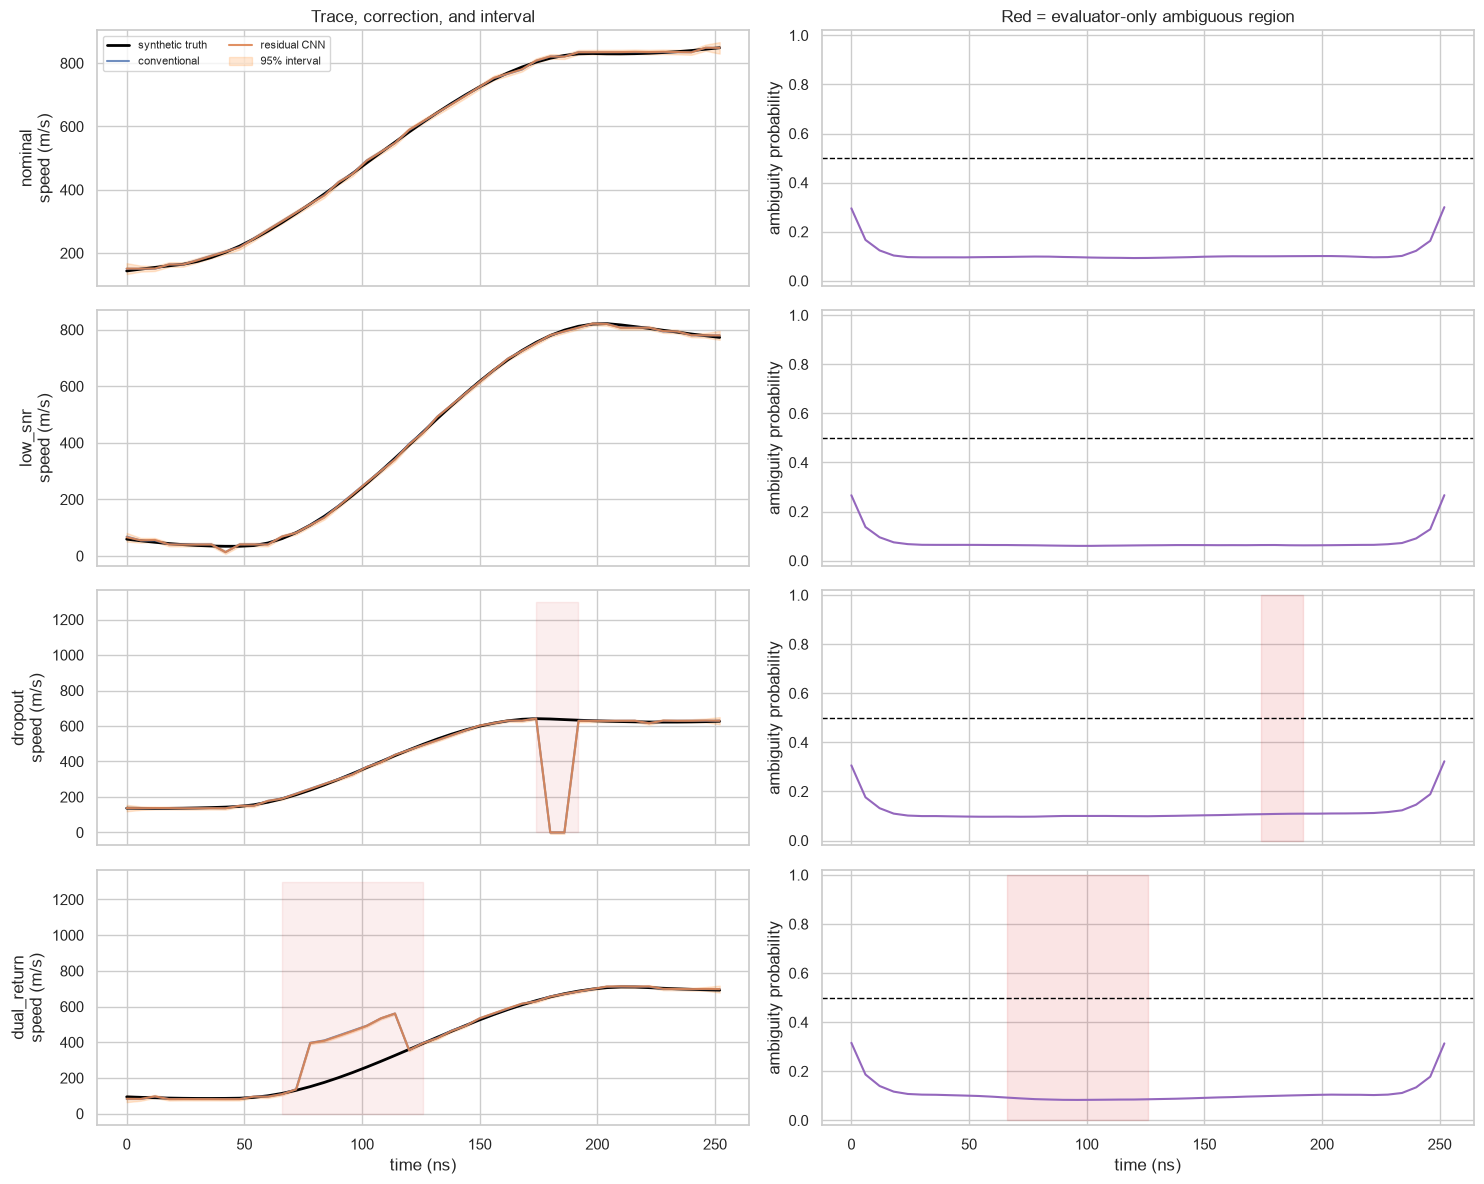

In [9]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
plot_velocity=dev_shots.groupby(['regime','method']).MAE.mean().reset_index()
sns.barplot(data=plot_velocity,x='regime',y='MAE',hue='method',ax=axes[0])
axes[0].set_title('Development velocity error'); axes[0].set_ylabel('shot-mean MAE (m/s)')
axes[0].tick_params(axis='x',rotation=20)

axes[1].plot(100*risk_dev.abstained_fraction,risk_dev.retained_MAE,'o-',label='MAE')
axes[1].plot(100*risk_dev.abstained_fraction,risk_dev.retained_p95,'o-',label='95th percentile')
axes[1].set(xlabel='highest-risk usable frames abstained (%)',ylabel='error (m/s)',
            title='Does predicted uncertainty rank errors?'); axes[1].legend()

axes[2].bar(interval_dev.index,100*interval_dev.coverage_95)
axes[2].axhspan(90,98,color='tab:green',alpha=.15,label='provisional target')
axes[2].axhline(95,color='black',linestyle='--',linewidth=1)
axes[2].set(xlabel='regime',ylabel='empirical coverage (%)',title='Nominal 95% intervals')
axes[2].tick_params(axis='x',rotation=20); axes[2].legend()
plt.tight_layout(); plt.show()

fig,axes=plt.subplots(4,2,figsize=(15,12),sharex='col')
for row,regime in enumerate(REGIMES):
    ex=dev_examples[regime]; x=ex['time']*1e9; band=1.96*SIGMA_SCALE*ex['raw_sigma']
    axes[row,0].plot(x,ex['truth'],color='black',linewidth=2,label='synthetic truth')
    axes[row,0].plot(x,ex['continuity'],alpha=.8,label='conventional')
    axes[row,0].plot(x,ex['cnn'],alpha=.9,label='residual CNN')
    axes[row,0].fill_between(x,ex['cnn']-band,ex['cnn']+band,color='tab:orange',alpha=.18,label='95% interval')
    axes[row,0].fill_between(x,0,MAX_SPEED,where=ex['amb'],color='tab:red',alpha=.08)
    axes[row,0].set_ylabel(f'{regime}\nspeed (m/s)')
    axes[row,1].plot(x,ex['ambiguity_prob'],color='tab:purple')
    axes[row,1].axhline(AMBIGUITY_THRESHOLD,color='black',linestyle='--',linewidth=1)
    axes[row,1].fill_between(x,0,1,where=ex['amb'],color='tab:red',alpha=.12)
    axes[row,1].set_ylim(-.02,1.02); axes[row,1].set_ylabel('ambiguity probability')
axes[0,0].legend(ncol=2,fontsize=8); axes[0,0].set_title('Trace, correction, and interval')
axes[0,1].set_title('Red = evaluator-only ambiguous region')
axes[-1,0].set_xlabel('time (ns)'); axes[-1,1].set_xlabel('time (ns)')
plt.tight_layout(); plt.show()

## 5. Frozen acceptance contract and one-time locked evaluation

The following thresholds are frozen before the locked cells execute. They are **provisional research gates**, not validated facility requirements.

- In no regime may CNN shot-mean MAE exceed continuity MAE by more than **1 m/s**.
- Overall 95% interval coverage on usable frames must be between **90% and 98%**.
- Fewer than **10%** of truly ambiguous frames may receive an ambiguity probability below 0.5.
- Fewer than **20%** of usable frames may be falsely flagged ambiguous.
- Abstaining on the 10% of usable frames with the largest predicted uncertainty must reduce retained MAE by at least **20%**.

Opening the test consumes `pdv-robust-v1-seeds-30000-30047`. Any later model or threshold change requires a newly seeded test version.

In [10]:
MAX_REGIME_DEGRADATION=1.0
COVERAGE_RANGE=(.90,.98)
MAX_AMBIGUOUS_FALSE_CONFIDENCE=.10
MAX_USABLE_FALSE_ALARM=.20
MIN_MAE_REDUCTION_AT_10PCT_ABSTENTION=.20

if not OPEN_LOCKED_TEST:
    print('LOCKED TEST REMAINS CLOSED. Develop using train and dev only.')
else:
    locked_shots,locked_frames,locked_examples=evaluate_shots(locked,best['model'])
    locked_frames['calibrated_sigma']=locked_frames.raw_sigma*SIGMA_SCALE
    locked_velocity=(locked_shots.groupby(['regime','method'])
                     [['MAE','bias','p95_abs_error']].mean().round(2))
    usable=locked_frames.loc[~locked_frames.ambiguous].copy()
    coverage=float((np.abs(usable.cnn-usable.truth)<=1.96*usable.calibrated_sigma).mean())
    width=float((2*1.96*usable.calibrated_sigma).mean())
    ambiguous=locked_frames.ambiguous
    false_conf=float((locked_frames.loc[ambiguous,'ambiguity_prob']<AMBIGUITY_THRESHOLD).mean())
    false_alarm=float((locked_frames.loc[~ambiguous,'ambiguity_prob']>=AMBIGUITY_THRESHOLD).mean())
    locked_risk=risk_curve(locked_frames)
    full_mae=float(locked_risk.loc[locked_risk.retained_fraction==1.0,'retained_MAE'].iloc[0])
    mae90=float(locked_risk.loc[locked_risk.retained_fraction==.90,'retained_MAE'].iloc[0])
    reduction=(full_mae-mae90)/full_mae

    regime_means=locked_shots.groupby(['regime','method']).MAE.mean().unstack()
    worst_degradation=float((regime_means['residual CNN']-regime_means['continuity']).max())
    gates=pd.DataFrame([
        {'gate':'worst regime CNN degradation <= 1 m/s','value':worst_degradation,'passed':worst_degradation<=MAX_REGIME_DEGRADATION},
        {'gate':'95% coverage between 90% and 98%','value':coverage,'passed':COVERAGE_RANGE[0]<=coverage<=COVERAGE_RANGE[1]},
        {'gate':'ambiguous false confidence <= 10%','value':false_conf,'passed':false_conf<=MAX_AMBIGUOUS_FALSE_CONFIDENCE},
        {'gate':'usable false alarm <= 20%','value':false_alarm,'passed':false_alarm<=MAX_USABLE_FALSE_ALARM},
        {'gate':'10% abstention reduces MAE >= 20%','value':reduction,'passed':reduction>=MIN_MAE_REDUCTION_AT_10PCT_ABSTENTION},
    ])
    locked_interval=(locked_frames.loc[~locked_frames.ambiguous].assign(
        covered=lambda d: np.abs(d.cnn-d.truth)<=1.96*d.calibrated_sigma,
        width_95=lambda d: 2*1.96*d.calibrated_sigma)
        .groupby('regime')[['covered','width_95']].mean()
        .rename(columns={'covered':'coverage_95'}).round(3))
    ambiguity_rows=[]
    for regime,group in locked_frames.groupby('regime'):
        pos=group.ambiguous
        ambiguity_rows.append({'regime':regime,'ambiguous_prevalence':pos.mean(),
            'ambiguous_recall':float((group.loc[pos,'ambiguity_prob']>=AMBIGUITY_THRESHOLD).mean()) if pos.any() else np.nan,
            'usable_false_alarm':float((group.loc[~pos,'ambiguity_prob']>=AMBIGUITY_THRESHOLD).mean())})
    locked_ambiguity=pd.DataFrame(ambiguity_rows).set_index('regime').round(3)

    print('LOCKED TEST CONSUMED:',LOCKED_TEST_ID)
    print('Velocity errors: shot means (m/s)'); display(locked_velocity)
    print('Interval calibration by regime'); display(locked_interval)
    print('Ambiguity behavior by regime'); display(locked_ambiguity)
    print(f'Overall interval coverage={coverage:.3f}; mean 95% width={width:.2f} m/s')
    print(f'Ambiguous false confidence={false_conf:.3f}; usable false alarm={false_alarm:.3f}')
    display(locked_risk.round(3)); display(gates.round(3))
    print('OVERALL:', 'PASS' if gates.passed.all() else 'FAIL')

LOCKED TEST CONSUMED: pdv-robust-v1-seeds-30000-30047
Velocity errors: shot means (m/s)


MAE  bias  p95_abs_error
regime      method                                 
dropout     continuity    3.54 -0.07           7.20
            peak          3.54 -0.07           7.20
            residual CNN  3.54 -0.21           7.29
dual_return continuity    3.56  0.68           7.11
            peak          3.56  0.68           7.11
            residual CNN  3.51  0.56           6.90
low_snr     continuity    3.77  0.06           7.60
            peak          3.77  0.06           7.60
            residual CNN  3.78 -0.38           7.80
nominal     continuity    3.43  0.47           6.82
            peak          3.43  0.47           6.82
            residual CNN  3.43  0.34           6.80

Interval calibration by regime


,coverage_95,width_95
regime,,
dropout,0.971,16.275999
dual_return,0.977,16.197001
low_snr,0.874,13.799000
nominal,0.971,16.125999


Ambiguity behavior by regime


,ambiguous_prevalence,ambiguous_recall,usable_false_alarm
regime,,,
dropout,0.122,0.0,0.0
dual_return,0.163,0.0,0.0
low_snr,0.000,NaN,0.0
nominal,0.000,NaN,0.0


Overall interval coverage=0.946; mean 95% width=15.55 m/s
Ambiguous false confidence=1.000; usable false alarm=0.000


,retained_fraction,abstained_fraction,retained_MAE,retained_p95
0,1.00,0.00,3.570,7.370
1,0.95,0.05,3.463,7.102
2,0.90,0.10,3.441,7.097
3,0.80,0.20,3.436,7.131
4,0.70,0.30,3.462,7.200
5,0.50,0.50,3.439,7.314


,gate,value,passed
0,worst regime CNN degradation <= 1 m/s,0.010,True
1,95% coverage between 90% and 98%,0.946,True
2,ambiguous false confidence <= 10%,1.000,False
3,usable false alarm <= 20%,0.000,True
4,10% abstention reduces MAE >= 20%,0.036,False


OVERALL: FAIL


### Post-test audit

The preregistered **overall** interval gate passed, but the added regime audit found only **87.4% coverage in low SNR**, below the provisional 90% lower bound. Do not rewrite the completed gate after seeing the answer. Record this as a weakness in the v1 contract, and require per-regime coverage gates in v2.

The main failure is sharper: ambiguity recall is zero in both dropout and dual-return cases. The network learned that predicting “not ambiguous” minimizes the imbalanced classification loss. Its uncertainty scale is reasonably calibrated on average, but it does not rank errors strongly enough to make abstention useful.

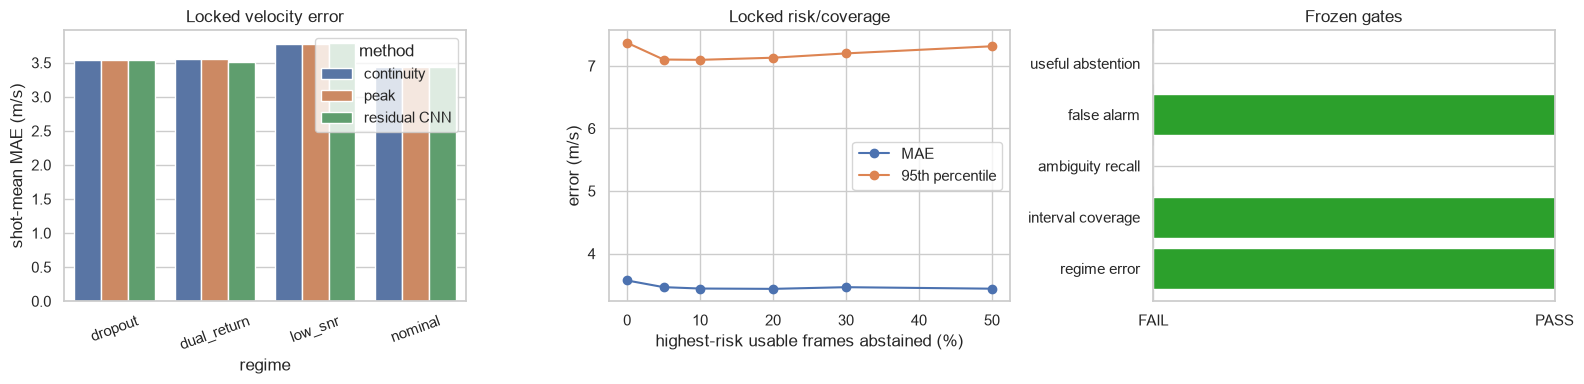

In [11]:
if OPEN_LOCKED_TEST:
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    plot_velocity=locked_shots.groupby(['regime','method']).MAE.mean().reset_index()
    sns.barplot(data=plot_velocity,x='regime',y='MAE',hue='method',ax=axes[0])
    axes[0].set_title('Locked velocity error'); axes[0].set_ylabel('shot-mean MAE (m/s)')
    axes[0].tick_params(axis='x',rotation=20)
    axes[1].plot(100*locked_risk.abstained_fraction,locked_risk.retained_MAE,'o-',label='MAE')
    axes[1].plot(100*locked_risk.abstained_fraction,locked_risk.retained_p95,'o-',label='95th percentile')
    axes[1].set(xlabel='highest-risk usable frames abstained (%)',ylabel='error (m/s)',title='Locked risk/coverage')
    axes[1].legend()
    colors=['tab:green' if p else 'tab:red' for p in gates.passed]
    axes[2].barh(np.arange(len(gates)),gates.passed.astype(int),color=colors)
    axes[2].set_yticks(np.arange(len(gates)),['regime error','interval coverage','ambiguity recall','false alarm','useful abstention'])
    axes[2].set_xlim(0,1); axes[2].set_xticks([0,1],['FAIL','PASS']); axes[2].set_title('Frozen gates')
    plt.tight_layout(); plt.show()

## 6. How to interpret this test

A velocity improvement answers only the correction question. Calibrated interval coverage answers whether the stated uncertainty has the right frequency inside this simulator. The risk curve answers whether uncertainty ranks errors well enough to support abstention. The ambiguity metrics answer whether the model recognizes deliberately non-identifiable two-return or dropout intervals.

A failed gate is retained as evidence. After this locked set is opened, change the model only against training/development data and create a newly seeded locked set for the next version. Passing this synthetic benchmark would still not validate a real PDV reconstruction or any claim about melting, ETI, MRTI, or driver–liner coupling.

## 7. Bridge to a real waveform

Before replacing one synthetic `voltage` array, record the sample interval, laser wavelength, trigger reference, voltage units, detector and digitizer bandwidth, filtering already applied, saturation codes, lost-return intervals, and every processing step. Keep the raw waveform immutable.

Compare with an analyst trace as a second reconstruction with its own assumptions, not as perfect truth. A second optical reference, independent motion diagnostic, or controlled stationary reference may be required to separate material motion from optical-path drift.

## Remaining work

- [ ] Verify the Viterbi implementation against a hand-constructed ridge.
- [x] Scale neural uncertainty using development data.
- [x] Freeze regime-specific gates before opening the versioned test.
- [x] Evaluate repeated initialization seeds.
- [x] Report correction, calibration, ambiguity, and abstention separately.
- [ ] Add a forward generator implemented independently from the inverse pipeline.
- [ ] Add timing, wavelength, bandwidth, saturation, and clock uncertainty.
- [ ] Decide from the intended use whether a dual return has a defined primary target or requires abstention.
- [ ] Estimate shot-level confidence intervals across a larger number of independent shots.
- [ ] Inspect one real waveform without treating its analyst reconstruction as perfect truth.